In [1]:
!pwd

/work/pi_jensen_umass_edu/jnainani_umass_edu/plan_trace/notebooks


In [2]:
%cd ..

/work/pi_jensen_umass_edu/jnainani_umass_edu/temporal_activation_patching


In [4]:
!python temp_patching/semi_super_mbpp_try.py

`get_ipython` not available. This script is not running in IPython.
Using device: cuda
{'source_file': 'Benchmark Questions Verification V2.ipynb', 'task_id': 2, 'prompt': 'Write a function to find the shared elements from the given two lists.', 'code': 'def similar_elements(test_tup1, test_tup2):\n  res = tuple(set(test_tup1) & set(test_tup2))\n  return (res) ', 'test_imports': [], 'test_list': ['assert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))', 'assert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))', 'assert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))']}
{'source_file': 'Benchmark Questions Verification V2.ipynb', 'task_id': 3, 'prompt': 'Write a python function to identify non-prime numbers.', 'code': 'import math\ndef is_not_prime(n):\n    result = False\n    for i in range(2,int(math.sqrt(n)) + 1):\n        if n % i == 0:\n            result = True\n    return result', 'test_imports': [], 'test_list': ['assert 

# Getting the dataset

In [1]:
import os
import requests

destination_folder = "../data/external/"

url = "https://raw.githubusercontent.com/google-research/google-research/master/mbpp/mbpp.jsonl"
filename = "mbpp.jsonl"

# Ensure the destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Full path where file will be saved
file_path = os.path.join(destination_folder, filename)

# Download the file
response = requests.get(url)
response.raise_for_status()  # Raise an error if the download fails

with open(file_path, 'wb') as f:
    f.write(response.content)

print(f"Downloaded {filename} to {file_path}")

filename = "sanitized-mbpp.json"
file_path = os.path.join(destination_folder, filename)
# Download the file
url = "https://raw.githubusercontent.com/google-research/google-research/master/mbpp/sanitized-mbpp.json"
response = requests.get(url)
response.raise_for_status()  # Raise an error if the download fails
with open(file_path, 'wb') as f:
    f.write(response.content)
print(f"Downloaded {filename} to {file_path}")

Downloaded mbpp.jsonl to ../data/external/mbpp.jsonl
Downloaded sanitized-mbpp.json to ../data/external/sanitized-mbpp.json


# Loading it

In [2]:
import json, os, tempfile, time, multiprocessing as mp, subprocess, sys, requests, psutil
from pathlib import Path

In [3]:
# load a normal json file
destination_folder = "../data/external/"
filename = "sanitized-mbpp.json"
file_path = os.path.join(destination_folder, filename)
with open(file_path, 'r') as f:
    data = json.load(f)
# Print the first 5 entries
for i in range(5):
    print(data[i])

{'source_file': 'Benchmark Questions Verification V2.ipynb', 'task_id': 2, 'prompt': 'Write a function to find the shared elements from the given two lists.', 'code': 'def similar_elements(test_tup1, test_tup2):\n  res = tuple(set(test_tup1) & set(test_tup2))\n  return (res) ', 'test_imports': [], 'test_list': ['assert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))', 'assert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))', 'assert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))']}
{'source_file': 'Benchmark Questions Verification V2.ipynb', 'task_id': 3, 'prompt': 'Write a python function to identify non-prime numbers.', 'code': 'import math\ndef is_not_prime(n):\n    result = False\n    for i in range(2,int(math.sqrt(n)) + 1):\n        if n % i == 0:\n            result = True\n    return result', 'test_imports': [], 'test_list': ['assert is_not_prime(2) == False', 'assert is_not_prime(10) == True', 'assert is_not_prime(35) 

# Getting tf lens model

In [4]:
"""
Shape Suffix Definition: 

- B: batch size 
- L: Num of Input Tokens 
- O: Num of Output Tokens
- V: vocabulary size
- F: feed-forward subnetwork hidden size
- D: Depth or number of layers
- H: number of attention heads in a layer
- S: Number of SAE neurons in a layer
- A: Number of SAEs attached
- tx: variables dealing with the prediction of the x'th output token
"""

import sys
import os
import torch
import transformer_lens
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch.nn.functional as F
import re
from sae_lens import SAE
from tqdm import tqdm
from functools import partial, lru_cache
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
import pandas as pd
from typing import TypedDict, Optional, Tuple, Union
import random
import wandb
import signal
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append("../")

from plan_trace.utils import load_model, load_pretrained_saes, cleanup_cuda
from plan_trace.hooks import run_with_saes, register_sae_hooks
from sae_lens import HookedSAETransformer, SAE
# sys.path.append("../temp_patching/")
# from utils import (
#     load_model, 
#     logit_diff_fn, 
#     patching_metric_denoising, 
#     patching_metric_noising,
#     get_device,
#     cleanup_cuda,
#     get_saes,
#     get_sae_id,
#     get_pretrained_saes_ids
# )
# from utils_legacy import (
#     run_sae_hook_fn,
#     build_sae_hook_fn
# )

# from dataset import (
#     get_dataset,
#     get_tk_prompt
# )

# from circ_utils import (
#     SAEMasks,
#     clear_memory,
#     run_integrated_gradients,
#     load_pretrained_saes, 
#     calculate_and_plot_ig_effects
# )

# from hooks import AdaptableHook
device = "cuda"

In [5]:

# ----------------------------------------------------------------------
# 2) Model -------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "google/gemma-2b-it"       # CC-BY-NC-SA-4.0
model_name = "gemma-2-2b"
model = load_model(model_name, device = device, use_custom_cache=True, dtype=torch.bfloat16)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


# Testing one example first

In [6]:
# ── add near the top, beside the other imports ──────────────────────────────────
import re, textwrap
# ────────────────────────────────────────────────────────────────────────────────

def extract_code(txt: str) -> str:
    """
    Return the first fenced-code block found in `txt`.

    The block may start with ```python or plain ```; the closing fence must be ```.

    If no fence is present we fall back to returning the whole string.
    """
    m = re.search(r"```(?:python)?\s*(.*?)```", txt, flags=re.S | re.I)
    if m:
        # Remove any common indentation the model might add
        return textwrap.dedent(m.group(1)).strip()
    return txt.strip()

def extract_code_strict(txt: str) -> str:
    """
    Return the first fenced-code block found in `txt`.

    The block may start with ```python or plain ```; the closing fence must be ```.

    If no fence is present we fall back to returning the whole string.
    """
    m = re.search(r"```(?:python)?\s*(.*?)```", txt, flags=re.S | re.I)
    if m:
        # Remove any common indentation the model might add
        return textwrap.dedent(m.group(1)).strip()
    return False

# ----------------------------------------------------------------------
# 3) Sand-boxed test runner ----------------------------------------------------
def _worker(code: str, tests: list[str], queue):
    """
    Child process: exec supplied code, then run tests.
    Sends (passed, error_msg) back through Queue.
    """
    try:
        ns = {}
        exec(code, ns)

        for test in tests:
            # Each test is an assert statement string, e.g.
            # "assert add(1, 2) == 3"
            exec(test, ns)
        queue.put((True, ""))
    except Exception as e:
        queue.put((False, repr(e)))

def run_tests(code: str, tests: list[str], timeout=15) -> bool:
    """
    Returns True if *all* tests pass within the timeout.
    """
    q = mp.Queue()
    p = mp.Process(target=_worker, args=(code, tests, q))
    p.start()
    p.join(timeout)
    if p.is_alive():
        # kill runaway child (and its children)
        proc = psutil.Process(p.pid)
        for ch in proc.children(recursive=True):
            ch.kill()
        proc.kill()
        p.join()
        return False
    passed, _ = q.get() if not q.empty() else (False, "no-result")
    return passed

In [7]:
print(data[0])

{'source_file': 'Benchmark Questions Verification V2.ipynb', 'task_id': 2, 'prompt': 'Write a function to find the shared elements from the given two lists.', 'code': 'def similar_elements(test_tup1, test_tup2):\n  res = tuple(set(test_tup1) & set(test_tup2))\n  return (res) ', 'test_imports': [], 'test_list': ['assert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))', 'assert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))', 'assert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))']}


In [8]:
i = 26
text_question = data[i]['prompt']
test_cases = data[i]['test_list']
# print(text_question)
# print(test_cases)

base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code, without docstrings, below starting with "```python" and ending with "```".\n"""

combined_prompt = base_prompt.format(
    prompt=text_question,
    tests="\n".join(test_cases),
)
print(combined_prompt)

You are an expert Python programmer, and here is your task: Write a python function to check whether the given array is monotonic or not. Your code should pass these tests:

assert is_Monotonic([6, 5, 4, 4]) == True
assert is_Monotonic([1, 2, 2, 3]) == True
assert is_Monotonic([1, 3, 2]) == False
Write your code, without docstrings, below starting with "```python" and ending with "```".



In [12]:
data[i]['code']

'def is_Monotonic(A): \n    return (all(A[i] <= A[i + 1] for i in range(len(A) - 1)) or\n            all(A[i] >= A[i + 1] for i in range(len(A) - 1))) '

In [13]:
toks = model.to_tokens(combined_prompt).to(device)
with torch.no_grad():
    out = model.generate(
        toks,
        do_sample=False,
        max_new_tokens=200
    )
code_block  = extract_code(model.to_string(out[0][toks.size(1):]))  
print(code_block)
run_tests(code_block, test_cases)

  0%|          | 0/200 [00:00<?, ?it/s]

def is_Monotonic(arr):
    increasing = True
    decreasing = True
    for i in range(len(arr) - 1):
        if arr[i] > arr[i + 1]:
            increasing = False
        if arr[i] < arr[i + 1]:
            decreasing = False
    return increasing or decreasing


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


True

# first 100 passing examples 

In [ ]:
# Initialize variables
pass_cnt = 0
passing_examples = []  # Store the first 100 passing examples

for i, example in tqdm(enumerate(data)):
    text_question = example['prompt']
    test_cases = example['test_list']

    # Prepare the prompt
    base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code, without docstrings, below starting with "```python" and ending with "```".\n"""
    combined_prompt = base_prompt.format(
        prompt=text_question,
        tests="\n".join(test_cases),
    )

    # Tokenize and generate code
    toks = model.to_tokens(combined_prompt).to(device)
    with torch.no_grad():
        out = model.generate(
            toks,
            do_sample=False,
            max_new_tokens=200
        )
    code_block = extract_code(model.to_string(out[0][toks.size(1):]))

    # Run tests
    if run_tests(code_block, test_cases):
        pass_cnt += 1
        passing_examples.append(example)  # Add the passing example to the list

    # Stop after finding 100 passing examples
    if len(passing_examples) >= 100:
        break

print(f"\nFound {len(passing_examples)} passing examples.")
print(f"Pass rate: {pass_cnt}/{len(data)} → {pass_cnt/len(data):.3%}")

# Save the first 100 passing examples to a JSON file
output_path = os.path.join(destination_folder, "first_100_passing_examples_without_docstrings.json")
with open(output_path, "w") as f:
    json.dump(passing_examples, f, indent=4)

print(f"Saved the first 100 passing examples to {output_path}")

## base checking 

In [9]:
# Load the first 100 passing examples from a JSON file into data_it
input_path = os.path.join(destination_folder, "first_100_passing_examples_without_docstrings.json")
with open(input_path, "r") as f:
    data_it = json.load(f)

In [11]:
i = 26
text_question = data_it[i]['prompt']
test_cases = data_it[i]['test_list']
# print(text_question)
# print(test_cases)

base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code below starting with "```python" and ending with "```".\n"""

combined_prompt = base_prompt.format(
    prompt=text_question,
    tests="\n".join(test_cases),
)
print(combined_prompt)

You are an expert Python programmer, and here is your task: Write a function to find the closest smaller number than n. Your code should pass these tests:

assert closest_num(11) == 10
assert closest_num(7) == 6
assert closest_num(12) == 11
Write your code below starting with "```python" and ending with "```".



In [12]:
toks = model.to_tokens(combined_prompt).to(device)
with torch.no_grad():
    out = model.generate(
        toks,
        do_sample=False,
        max_new_tokens=200
    )
code_block  = extract_code(model.to_string(out[0][toks.size(1):]))  
print(code_block)
run_tests(code_block, test_cases)

  0%|          | 0/200 [00:00<?, ?it/s]

def closest_num(n):
    return n - 1


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


True

In [14]:
# Initialize variables
pass_cnt = 0
passing_examples = []  # Store the first 100 passing examples
failed_examples = []

# Define output paths for incremental saving
pass_output_path = os.path.join(destination_folder, "first_100_passing_examples_without_docstrings_base_model_og_prompt.json")
fail_output_path = os.path.join(destination_folder, "first_100_failing_examples_without_docstrings_base_model_og_prompt.json")

for i, example in tqdm(enumerate(data_it)):
    text_question = example['prompt']
    test_cases = example['test_list']

    # Prepare the prompt
    base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code below starting with "```python" and ending with "```".\n"""
    combined_prompt = base_prompt.format(
        prompt=text_question,
        tests="\n".join(test_cases),
    )

    # Tokenize and generate code
    toks = model.to_tokens(combined_prompt).to(device)
    with torch.no_grad():
        out = model.generate(
            toks,
            do_sample=False,
            max_new_tokens=200
        )
    code_block = extract_code(model.to_string(out[0][toks.size(1):]))

    # Attach model output to the example we save
    example_with_output = dict(example)
    example_with_output["model_output"] = code_block

    # Run tests
    if run_tests(code_block, test_cases):
        pass_cnt += 1
        passing_examples.append(example_with_output)
        # Incremental, atomic save for passing examples
        tmp_path = pass_output_path + ".tmp"
        with open(tmp_path, "w") as f:
            json.dump(passing_examples, f, indent=4)
        os.replace(tmp_path, pass_output_path)
    else:
        failed_examples.append(example_with_output)
        # Incremental, atomic save for failing examples
        tmp_path = fail_output_path + ".tmp"
        with open(tmp_path, "w") as f:
            json.dump(failed_examples, f, indent=4)
        os.replace(tmp_path, fail_output_path)

    # Stop after finding 100 passing examples
    if len(passing_examples) >= 100:
        break

print(f"\nFound {len(passing_examples)} passing examples.")
print(f"Pass rate: {pass_cnt}/{len(data_it)} → {pass_cnt/len(data_it):.3%}")

# Final save to ensure files reflect the last state
with open(pass_output_path, "w") as f:
    json.dump(passing_examples, f, indent=4)
with open(fail_output_path, "w") as f:
    json.dump(failed_examples, f, indent=4)

print(f"Saved passing to {pass_output_path} and failing to {fail_output_path}")

0it [00:00, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
1it [00:00,  3.50it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2it [00:07,  4.12s/it]

...

  0%|          | 0/200 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
99it [01:30,  1.04it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100it [01:31,  1.10it/s]


Found 10 passing examples.
Pass rate: 10/100 → 10.000%
Saved passing to ../data/external/first_100_passing_examples_without_docstrings_base_model_og_prompt.json and failing to ../data/external/first_100_failing_examples_without_docstrings_base_model_og_prompt.json


# filtering intermediate tokens? maybe

In [9]:
text_question = data[0]['prompt']
test_cases = data[0]['test_list']

# Prepare the prompt
base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code below starting with "```python" and ending with "```".\n```python\n"""
combined_prompt = base_prompt.format(
    prompt=text_question,
    tests="\n".join(test_cases),
)

# Tokenize and generate code
toks = model.to_tokens(combined_prompt).to(device)
changable_toks = toks.clone()
# for i in range(10):
while True:
    with torch.no_grad():
        logits_BLV = model(changable_toks)
        logits_BV = logits_BLV[:, -1, :]
        top_token = torch.argmax(logits_BV).item()
        # print(model.to_string([top_token]))
        if top_token == 1917:
            break
        changable_toks = torch.cat([changable_toks, torch.tensor([[top_token]], device=device)], dim=1)
        # if extract_code_strict(model.to_string(changable_toks[0][toks.size(1):])):

print(model.to_string(changable_toks[0][toks.size(1):]))

def similar_elements(list1, list2):
    """
    Finds the shared elements from the given two lists.

    Args:
        list1: The first list.
        list2: The second list.

    Returns:
        A set containing the shared elements.
    """
    return set(list1).intersection(set(list2))



In [10]:
print(model.to_str_tokens(model.to_string(changable_toks[0][toks.size(1):])))

['<bos>', 'def', ' similar', '_', 'elements', '(', 'list', '1', ',', ' list', '2', '):', '\n', '    ', '"""', '\n', '    ', 'Find', 's', ' the', ' shared', ' elements', ' from', ' the', ' given', ' two', ' lists', '.', '\n\n', '    ', 'Args', ':', '\n', '        ', 'list', '1', ':', ' The', ' first', ' list', '.', '\n', '        ', 'list', '2', ':', ' The', ' second', ' list', '.', '\n\n', '    ', 'Returns', ':', '\n', '        ', 'A', ' set', ' containing', ' the', ' shared', ' elements', '.', '\n', '    ', '"""', '\n', '    ', 'return', ' set', '(', 'list', '1', ').', 'intersection', '(', 'set', '(', 'list', '2', '))', '\n']


In [24]:
text_question = data[0]['prompt']
test_cases = data[0]['test_list']

# Prepare the prompt
base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code below starting with "```python" and ending with "```".\n```python\n"""
combined_prompt = base_prompt.format(
    prompt=text_question,
    tests="\n".join(test_cases),
)

# Tokenize and generate code
toks = model.to_tokens(combined_prompt).to(device)
changable_toks = toks.clone()
# for i in range(10):
while True:
    with torch.no_grad():
        # print(changable_toks.shape[-1])
        logits_BLV = model(changable_toks)
        logits_BV = logits_BLV[:, -1, :]
        top_token = torch.argmax(logits_BV).item()
        
        if top_token == 1917:
            break
        str_top_token = model.to_string([top_token]) #[0]
        # print(str_top_token)
        prompt_current = model.to_string(changable_toks[0])
        if not str_top_token.strip() in prompt_current:
            print(changable_toks.shape[-1])
            print(model.to_string([top_token]))
            
        changable_toks = torch.cat([changable_toks, torch.tensor([[top_token]], device=device)], dim=1)
        # if extract_code_strict(model.to_string(changable_toks[0][toks.size(1):])):
        

print(model.to_string(changable_toks[0][toks.size(1):]))

181
def
191
):
194
"""
197
Find
210
Args
217
 The
218
 first
227
 second
232
Returns
238
 containing
248
return
253
).
254
intersection
def similar_elements(list1, list2):
    """
    Finds the shared elements from the given two lists.

    Args:
        list1: The first list.
        list2: The second list.

    Returns:
        A set containing the shared elements.
    """
    return set(list1).intersection(set(list2))



In [12]:
combined_prompt

'You are an expert Python programmer, and here is your task: Write a function to find the shared elements from the given two lists. Your code should pass these tests:\n\nassert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))\nassert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))\nassert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))\nWrite your code below starting with "```python" and ending with "```".\n```python\n'

In [13]:
from circ_utils import (
    SAEMasks,
    clear_memory,
    run_integrated_gradients,
    load_pretrained_saes,
)

from auto_plan_detect import (
    compute_metric,
    compute_k_metrics,
    plot_k_metrics,
    find_min_k_for_threshold, 
    check_latent_signals,
    iter_topk_negative_effects,
    display_activations,
    auto_detect_plan
)

layers = list(range(model.cfg.n_layers))
saes = load_pretrained_saes(layers=layers, release="gemma-scope-2b-pt-mlp-canonical", width="16k", device=device, canon=True)

Current token to predict: ):
Logits, all base MLP SAEs, with error: 19.875
Mean error term: torch.Size([1, 192, 2304])


26it [00:39,  1.51s/it]


Processing K=1
Processing K=5001
Processing K=10001
Processing K=15001
Processing K=20001
Processing K=25001
Processing K=30001
Processing K=35001
Processing K=40001
Processing K=45001
Processing K=50001
Processing K=55001
Found minimum K for absolute effects: 40001 (metric: 0.5312, target: 0.4000)


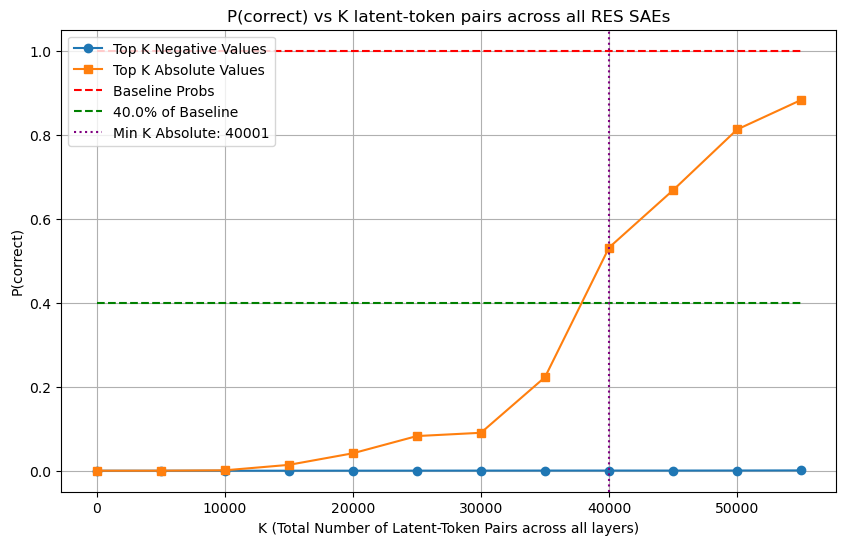

checking top‑K latents:  32%|███▏      | 12779/40001 [01:59<04:13, 107.34it/s]


KeyboardInterrupt: 

In [25]:
# Tokenize and generate code
toks = model.to_tokens(combined_prompt).to(device)
changable_toks = toks.clone()
# for i in range(10):
while True:
    # with torch.no_grad():
    base_save_dir = "../models/mbpp_task2_2b_mlp/"
    prompt_name = f"pred_{changable_toks.shape[-1]}/"
    save_dir = os.path.join(base_save_dir, prompt_name)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    model.reset_hooks(including_permanent=True)
    with torch.no_grad():
        logits_BLV = model(changable_toks)
    logits_BV = logits_BLV[:, -1, :]
    top_token = torch.argmax(logits_BV).item()
    str_top_token = model.to_string([top_token]) 
    prompt_current = model.to_string(changable_toks[0])

    if not str_top_token.strip() in prompt_current and changable_toks.shape[-1] > 189:
        print(f"Current token to predict: {str_top_token}")
        model.reset_hooks(including_permanent=True)
        
        auto_detect_plan(
            prompt=prompt_current,
            model=model,
            saes=saes,
            save_dir=save_dir,
            ig_steps=10,
            k_max=60001,
            k_step=5000,
            k_thres=0.4,
            device="cuda",
            save_and_use=False,
            logstats=False
            )
    if top_token == 1917:
        break
    changable_toks = torch.cat([changable_toks, torch.tensor([[top_token]], device=device)], dim=1)
    cleanup_cuda()
    clear_memory(saes, model)

In [20]:
prompt = """A rhyming couplet:
He saw a carrot and had to grab it,
"""

In [21]:

tokens = model.to_tokens(prompt)
changable_tokens = tokens.clone()

for i in range(7):
    print(model.to_string(changable_tokens[0]))
    prompt_current = model.to_string(changable_tokens[0])
    prompt_name = f"habit_poem_tok_{i}"
    save_dir = f"../models/tensors/{prompt_name}_2b_mlp_final_output/"

    auto_detect_plan(
            prompt=prompt_current,
            model=model,
            saes=saes,
            save_dir=save_dir,
            ig_steps=10,
            k_max=7001,
            k_step=500,
            k_thres=0.8,
            device="cuda"
    )
    with torch.no_grad():
        logits_BLV = model(changable_tokens)
    logits_BV = logits_BLV[0, -1, :]
    probs_BV = F.softmax(logits_BV, dim=-1)
    label = torch.argmax(logits_BV).item()

    changable_tokens = torch.cat([changable_tokens[0], torch.tensor([label]).to(device)]).unsqueeze(0).to(device)
    print("Output token", model.to_string(label))
    print("\n\n")



<bos>A rhyming couplet:
He saw a carrot and had to grab it,

Logits, all base MLP SAEs, with error: 19.75
Mean error term: torch.Size([1, 19, 2304])


0it [00:00, ?it/s]

[IG] Processing SAE 0 at hook blocks.0.hook_mlp_out ...
  [Step=0/10] ratio=0.0, metric=0.2715
  [Step=1/10] ratio=0.1, metric=0.2910
  [Step=2/10] ratio=0.2, metric=0.1914
  [Step=3/10] ratio=0.3, metric=0.1885
  [Step=4/10] ratio=0.4, metric=0.2344
  [Step=5/10] ratio=0.5, metric=0.2500
  [Step=6/10] ratio=0.6, metric=0.2158
  [Step=7/10] ratio=0.7, metric=0.1406
  [Step=8/10] ratio=0.8, metric=0.2480


1it [00:01,  1.26s/it]

  [Step=9/10] ratio=0.9, metric=0.2695
  => Saved SAE effect to ../models/tensors/habit_poem_tok_0_2b_mlp_final_output/sae_effect_0.pt
  => Saved Error effect to ../models/tensors/habit_poem_tok_0_2b_mlp_final_output/err_effect_0.pt
[IG] Processing SAE 1 at hook blocks.1.hook_mlp_out ...
  [Step=0/10] ratio=0.0, metric=0.2715
  [Step=1/10] ratio=0.1, metric=0.2910
  [Step=2/10] ratio=0.2, metric=0.2109
  [Step=3/10] ratio=0.3, metric=0.2363
  [Step=4/10] ratio=0.4, metric=0.2227
  [Step=5/10] ratio=0.5, metric=0.1582
  [Step=6/10] ratio=0.6, metric=0.1226


1it [00:02,  2.19s/it]

  [Step=7/10] ratio=0.7, metric=0.1631


KeyboardInterrupt: 

In [15]:
changable_toks[0].shape

torch.Size([262])

In [ ]:
text_question = data[0]['prompt']
test_cases = data[0]['test_list']

# Prepare the prompt
base_prompt = """You are an expert Python programmer, and here is your task: {prompt} Your code should pass these tests:\n\n{tests}\nWrite your code below starting with "```python" and ending with "```".\n```python\n"""
combined_prompt = base_prompt.format(
    prompt=text_question,
    tests="\n".join(test_cases),
)

# Tokenize and generate code
toks = model.to_tokens(combined_prompt).to(device)
changable_toks = toks.clone()
for i in range(7):
    print(model.to_string(changable_tokens[0]))
    prompt_current = model.to_string(changable_tokens[0])
    prompt_name = f"habit_poem_tok_{i}"
    save_dir = f"../models/tensors/{prompt_name}_2b_mlp_final_output/"

    auto_detect_plan(
            prompt=prompt_current,
            model=model,
            saes=saes,
            save_dir=save_dir,
            ig_steps=10,
            k_max=7001,
            k_step=500,
            k_thres=0.8,
            device="cuda"
    )
    with torch.no_grad():
        logits_BLV = model(changable_tokens)
    logits_BV = logits_BLV[0, -1, :]
    probs_BV = F.softmax(logits_BV, dim=-1)
    label = torch.argmax(logits_BV).item()

    changable_tokens = torch.cat([changable_tokens[0], torch.tensor([label]).to(device)]).unsqueeze(0).to(device)
    print("Output token", model.to_string(label))
    print("\n\n")

In [29]:
print(combined_prompt)

You are an expert Python programmer, and here is your task: Write a function to find the shared elements from the given two lists. Your code should pass these tests:

assert set(similar_elements((3, 4, 5, 6),(5, 7, 4, 10))) == set((4, 5))
assert set(similar_elements((1, 2, 3, 4),(5, 4, 3, 7))) == set((3, 4))
assert set(similar_elements((11, 12, 14, 13),(17, 15, 14, 13))) == set((13, 14))
Write your code below starting with "```python" and ending with "```".
```python



In [25]:
top_token

1917

In [24]:
model.to_string(top_token)

'```'

In [22]:
extract_code_strict(model.to_string(changable_toks[0][toks.size(1):]))

'def similar_elements(list1, list2):\n    """\n    Finds the shared elements from the given two lists.\n\n    Args:\n        list1: The first list.\n        list2: The second list.\n\n    Returns:\n        A set containing the shared elements.\n    """\n    return set(list1).intersection(set(list2))'

In [17]:
changable_toks.shape

torch.Size([1, 188])

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


False

In [22]:
print(data[0]['code'])

def similar_elements(test_tup1, test_tup2):
  res = tuple(set(test_tup1) & set(test_tup2))
  return (res) 


In [ ]:


# Helper for one generation ---------------------------------------------------
def generate_solution(prompt: str, max_new_tokens: int = 256) -> str:
    input_ids = tok(prompt, return_tensors="pt").input_ids.to(model.device)
    with torch.no_grad():
        gen_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,          # small amount of randomness often helps
            temperature=0.2,
            eos_token_id=tok.eos_token_id,
        )
    return tok.decode(gen_ids[0][input_ids.size(1):], skip_special_tokens=True)



# ----------------------------------------------------------------------
# 4) Main loop ---------------------------------------------------------------
pass_cnt = 0
total    = len(examples)

for ex in tqdm(examples, desc="Solving", unit="problem"):
    prompt      = ex["prompt"]
    tests       = ex["test_list"]          # list[str]
    full_prompt = (prompt.strip() +
                   "\n# Write your Python solution below.\n")
    candidate   = generate_solution(full_prompt)

    # Build a *single* script: user prompt (function signature) + candidate code
    code_block = prompt + "\n" + candidate
    if run_tests(code_block, tests):
        pass_cnt += 1

print(f"\n=== Gemma-2B-IT on MBPP (pass@1) ===")
print(f"{pass_cnt}/{total}  →  {pass_cnt/total:.3%}")


FileNotFoundError: Couldn't find a module script at /work/pi_jensen_umass_edu/jnainani_umass_edu/temporal_activation_patching/notebooks/mbpp/mbpp.py. Module 'mbpp' doesn't exist on the Hugging Face Hub either.